In [1]:
import sys
sys.path.append('../GC_stream')

from tqdm import tqdm
import numpy as np
import matplotlib as mpl
from matplotlib import colormaps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as PathEffects
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.stats import binned_statistic, binned_statistic_2d, gaussian_kde
from scipy.signal import find_peaks
from scipy.optimize import minimize
from scipy import linalg
from astropy.io import fits
import astropy.units as u
import astropy.coordinates as coord
import pandas as pd
from ezpadova import parsec

import gala.coordinates as galac
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

import agama
agama.setUnits(length=1, velocity=1, mass=1)

from cmcrameri.cm import batlow

import stream_dataset as sd
import GC
import agama_stream as ags

In [2]:
plt.rcParams['font.sans-serif'] = ['helvetica', 'DejaVu Sans',
                               'Lucida Grande', 'Verdana']

In [3]:
# force reimport

import importlib
importlib.reload(sd)
importlib.reload(GC)
importlib.reload(ags)

<module 'agama_stream' from '/Users/ybchen/Documents/GC_stream/notebooks/../GC_stream/agama_stream.py'>

In [4]:
def get_peri_apo(x,y,z):
    r2 = x**2 + y**2 + z**2
    median = np.median(r2)
    peaks_apo, _ = find_peaks(r2, height=median)
    peaks_peri, _ = find_peaks(-r2, height=-median)

    return peaks_apo, peaks_peri

**download and select isochrones**

In [5]:
# download isochrone

feh_list = np.array([-1.9, -1.5, -1.3, -1.1, -0.7])
Z_list = 10.0**feh_list*0.0152

# download gaia isochrone
# iso_list = [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='gaia') for Z in Z_list]
# for i in range(len(feh_list)):
#     iso_list[i].to_pandas().to_csv('../data/iso_gaia/feh%g.csv'%feh_list[i])

# download cfht isochrone
# iso_list = [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='megacam_wircam') for Z in Z_list]
# for i in range(len(feh_list)):
#     iso_list[i].to_pandas().to_csv('../data/iso_cfht/feh%g.csv'%feh_list[i])

In [6]:
# load isochrone

iso_gaia_list = []
for i in range(len(feh_list)):
    iso_gaia_list.append(pd.read_csv('../data/iso_gaia/feh%g.csv'%feh_list[i]))
    
iso_cfht_list = []
for i in range(len(feh_list)):
    iso_cfht_list.append(pd.read_csv('../data/iso_cfht/feh%g.csv'%feh_list[i]))

In [7]:
# select isochrone

def select_iso(color, mag, iso_list, color1_key, color2_key, mag_key):
    
    comp = np.inf
    idx = np.nan
    
    for j in range(len(iso_list)):
        iso = iso_list[j]
        iso_color1 = iso[color1_key]
        iso_color2 = iso[color2_key]
        iso_mag = iso[mag_key]
        
        mask = iso['label'] <= 3
        iso_color = iso_color1[mask][::-1]-iso_color2[mask][::-1]
        iso_mag = iso_mag[mask][::-1]

        dcolor = color - np.interp(mag, iso_mag, iso_color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j

    return idx

def calc_mass(mag, iso, mag_key):
    iso_mag = iso[mag_key]
    iso_Mini = iso['Mini']
    
    mask = iso['label'] <= 3
    iso_mag = iso_mag[mask][::-1]
    iso_Mini = iso_Mini[mask][::-1]
    return np.interp(mag, iso_mag, iso_Mini)

**name converter**

In [8]:
def display_name_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        )
    
def display_name_simple_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        .replace('NGC ', 'N')
        )

**detect segments from streams**

In [9]:
def detect_segs(stream, width=None, gap_angle=10, percentiles=[10,90], min_count=10):
    angle_tid = stream.prog['rt'] / stream.prog['Rsun'] * 1e-3 * 180 / np.pi
    if width is None:
        width = np.sqrt(np.mean(stream.phi2hat**2))
    segs = []
    if stream.prog_phi2hat < width and stream.prog_phi2hat > -width:
        maskl = (stream.phi1 < stream.prog_phi1 - angle_tid) 
        maskr = (stream.phi1 > stream.prog_phi1 + angle_tid)
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskl]), gap_angle, percentiles, min_count))
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskr]), gap_angle, percentiles, min_count))
    else:
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1), gap_angle, percentiles, min_count))
    return segs

def detect_gaps_in_arms(phi1_arm, gap_angle=10, percentiles=[10,90], min_count=10):
    cuts = [-np.inf]
    for i in range(len(phi1_arm)-1):
        if phi1_arm[i+1] - phi1_arm[i] >= gap_angle:
            cuts.append((phi1_arm[i+1] + phi1_arm[i])/2)
    cuts.append(np.inf)
    
    segs = []
    for i in range(len(cuts)-1):
        mask = (phi1_arm > cuts[i]) & (phi1_arm <= cuts[i+1])
        if len(phi1_arm[mask]) < 10:
            continue
        seg = np.percentile(phi1_arm[mask], percentiles)
        segs.append(seg)
        if len(phi1_arm[mask]) < min_count:
            continue
    return segs

**calculate Gaussian width for segments**

In [10]:
def calc_selection_function(stream, segs):
    gaussian_widths = []
    for seg in segs:
        mask = (stream.phi1 > seg[0]) & (stream.phi1 <= seg[1])
        gaussian_widths.append(calc_gaussian_width_seg(stream.phi2hat[mask]))
    return gaussian_widths

def calc_gaussian_width_seg(seg_phi2hat):
    return np.sqrt(np.mean(seg_phi2hat**2))

**mass function**

In [11]:
def kroupa(mmin, mmax):
    # for 0.5 < mmax < 1 and 0.08 < mmin < 1
    if mmin == 0:
        return -0.676877 * mmax**-0.3 + 1.19048
    if mmin < 0.5:
        return -0.676877 * mmax**-0.3 - 0.580180 * mmin**0.7 + 1.19048
    else:
        return -0.676877 * (mmax**-0.3 - mmin**-0.3)
kroupa = np.vectorize(kroupa)

def power_law_imf(mmin, mmax, slope):
    if np.abs(slope + 2) < 0.0001:
        return np.log(mmax) - np.log(mmin)
    return (mmax**(2+slope) - mmin**(2+slope)) / (2+slope)
    
def power_law_broken_imf(mmin, mmax, slope):
    if mmin < 0.08:
        if np.abs(slope + 2) < 0.0001:
            return np.log(mmax) - np.log(0.08) + (0.08**2 - mmin**2) * 0.08**slope / 2
        return (mmax**(2+slope) - 0.08**(2+slope)) / (2+slope) + (0.08**2 - mmin**2) * 0.08**slope / 2 
    return power_law_imf(mmin, mmax, slope)
power_law_broken_imf = np.vectorize(power_law_broken_imf)


### Load stream data

**load GC data**

In [12]:
# load GC info as pandas dataframe
gc = GC.load_GC()

In [13]:
# Load prog data from Ana's catalog

with fits.open('/Users/ybchen/Downloads/streams_full_summary.fits') as hdul:
    data = hdul[1].data
    header = hdul[1].header

progs = {}

for st in data:
    name = st[0]
    name = name.replace(' ', '_')
    name = name.replace('Palomar', 'Pal')
    # print(name)
    progs[name] = {
        'RA': st['ra'],
        'DEC': st['dec'],
        'Rsun': st['distance'],
        'mu_alpha': st['pmra'],
        'mu_delta': st['pmdec'],
        '<RV>': st['Vr'],
    }

In [14]:
for st in data:
    name = st[0]
    print(name, st['alt_name'])

20.0-1 
300S Gaia-10
ATLAS-Aliqa Uma 
Acheron 
Alpheus 
Aquarius 
C-10 
C-11 
C-12 
C-13 
C-19 
C-20 
C-22 
C-23 
C-24 
C-25 
C-4 
C-5 
C-7 
C-8 
C-9 
Cetus-Palca 
Cocytos 
Corvus 
Elqui 
Eridanus 
GD-1 
Gaia-1 
Gaia-11 
Gaia-12 
Gaia-2 
Gaia-3 
Gaia-4 
Gaia-5 
Gaia-6 
Gaia-7 
Gaia-8 
Gaia-9 
Gunnthra 
Hermus 
Hrid 
Hydrus 
Hyllus 
Indus 
Jet 
Jhelum 
Kshir 
Kwando 
Leiptr 
Lethe 
M2 NGC 7089
M3 Svol
M30 NGC 7099
M5 
M68 Fjorm
M92 
Molonglo 
Murrumbidgee 
NGC 1261 
NGC 1851 
NGC 2298 
NGC 2808 
NGC 288 
NGC 3201 Gjoll
NGC 5053 
NGC 5466 
NGC 5824 Triangulum
NGC 6101 
NGC 6362 
NGC 6397 
NGC 7492 
New-1 
New-10 
New-11 
New-12 
New-13 
New-14 
New-15 
New-16 
New-17 
New-18 
New-19 
New-2 
New-20 
New-21 
New-22 
New-23 
New-24 
New-25 
New-26 
New-27 
New-3 
New-4 
New-5 
New-6 
New-7 
New-8 
New-9 
Omega Centauri Fimbulthul
Ophiuchus 
Orinoco 
Orphan-Chenab 
PS1-A 
PS1-B 
PS1-C 
PS1-D 
PS1-E 
Palomar 13 
Palomar 15 
Palomar 5 
Parallel 
Pegasus 
Perpendicular 
Phlegethon 
Phoenix 
Rav

**load Ibata+24**

In [15]:
G_limit = 19

In [16]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}
ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

In [17]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = [
    'C-20', 'SGP-S', 'NGC_288', 'ATLAS-Aliqa_Uma', 'Phoenix', 'Kwando', 'New-1', 'New-2', 'C-13', 'Gaia-12', 'Hydrus', 'NGC_1261',
    'NGC_1261a', 'NGC_1261b', 'Indus', 'NGC_1851', 'New-3', 'New-4', 'Leiptr', 'C-12', 'New-5', 'New-6', 'NGC_2298', 'C-25',
    'C-11', 'NGC_2808', 'New-7', 'New-8', 'New-9', 'C-10', 'New-10', 'New-11', '300S', 'NGC_3201', 'C-9', 'C-24',
    'New-12', 'New-13', 'Slidr', 'New-14', 'Ylgr', 'Sylgr', 'New-15', 'Gaia-7', 'Gaia-8', 'New-16', 'M68', 'Orphan-Chenab',
    'Gaia-1', 'C-23', 'Wukong', 'C-22', 'GD-1', 'Omega_Centauri', 'Omega_Centauri-S', 'New-17', 'NGC_5466', 'New-18', 'Gaia-6', 'New-19',
    'Pal_5', 'M5', 'Kshir', 'M3', 'Gaia-9', 'Ophiuchus', 'NGC_6101', 'M92', 'NGC_6397', 'Gaia-11', 'Hrid', 'C-7',
    'New-20', 'New-21', 'Phlegethon', 'M2', 'M30', 'New-22', 'New-23', 'New-24', 'New-25', 'New-26', 'New-27', 'NGC_7492',
    'C-19', 'Jhelum', 'Tucana_III'
]
gc_stream_ids = np.array([
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
    13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
    25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
    37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48,
    49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
    61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
    85, 86, 87
], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    if not name in progs:
        print(name, 'not found')
        continue
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], progs[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

12it [00:38,  2.84s/it]

NGC_1261a not found
NGC_1261b not found


27it [01:29,  4.72s/it]/Users/ybchen/Documents/GC_stream/notebooks/../GC_stream/stream_dataset.py:131: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(self.phi1, self.phi2, deg=deg)
54it [03:05,  3.71s/it]

Omega_Centauri-S not found


87it [04:30,  3.10s/it]


**generate mock stream**

In [21]:
# generate mock stream

coord.galactocentric_frame_defaults.set ('v4.0')

pot_agama = agama.Potential("../data/MWPotential2014.ini")
pot_agama = agama.Potential("../data/PriceWhelan22.ini")
# pot_agama = agama.GalaPotential(gp.MilkyWayPotential2022())

t_tot = 2000 * u.Myr
dt = 4 * u.Myr # release 2 particles every time
release_type = 'uniform'
# release_type = 'peri_only'
n_steps = (t_tot/dt).value.astype(int)
nhalf = n_steps
assert nhalf % n_steps == 0

mockstreams = {}
T_dict = {}

# for key in ['Pal_5']:
for key in gc_stream_list:
    if not key in progs:
        print(key, 'not found')
        continue
    stream = ds_i24[key]
    
    # gc_mass = 10**stream.prog['logm']
    gc_mass = 10**5
    c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_pot = agama.Potential(type='Plummer', mass=gc_mass, scaleRadius=4e-3)
    gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]
    
    time_sat, orbit_sat = ags.integrate_prog( -t_tot.to('0.978*Gyr').value, n_steps, pot_agama, gc_posvel)
    peris, apos = get_peri_apo(orbit_sat[:,0], orbit_sat[:,1], orbit_sat[:,2])
    T_dict[key] = np.mean(np.r_[peris[1:] - peris[:-1], apos[1:] - apos[:-1]]) * t_tot.to('Gyr').value / n_steps
    
    if release_type == 'uniform':
        # release particles uniformly in time
        nhalf_release = np.full(n_steps, fill_value=nhalf/n_steps, dtype=int)
    elif release_type == 'peri_only':
        # release particles only at pericenters
        nhalf_per_release = nhalf // len(peris) + 1
        nhalf_release = np.zeros(n_steps, dtype=int)
        nhalf_release[peris] = nhalf_per_release
        nhalf_release[peris[0]] = nhalf - np.sum(nhalf_release[peris[1:]])
        assert nhalf_release[peris[0]] >= 0
    
    assert np.sum(nhalf_release) == nhalf
    
    time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
        ags.create_stream(ags.create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
            pot_agama, gc_posvel, gc_mass, pot_sat=gc_pot, nhalf_release=nhalf_release)
    
    mockstream = coord.Galactocentric(x=xv_stream[:,0]*u.kpc, y=xv_stream[:,1]*u.kpc, z=xv_stream[:,2]*u.kpc, 
        v_x=xv_stream[:,3]*u.km/u.s, v_y=xv_stream[:,4]*u.km/u.s, v_z=xv_stream[:,5]*u.km/u.s).transform_to(coord.ICRS())
    
    mockstream = sd.StreamDataset('mock', None, 
        mockstream.ra.to_value('deg'), mockstream.dec.to_value('deg'), 
        None, 
        mockstream.pm_ra_cosdec.to_value('mas/yr'), mockstream.pm_dec.to_value('mas/yr'), 
        None, None, 
        mockstream.distance.to_value('kpc'), mockstream.radial_velocity.to_value('km/s'), 
        None, None, None, stream.prog)
    
    mockstream.construct_greatcircle_coord(GreatCircle=stream.GreatCircle)
    mockstream.construct_polynomial_coord(p=stream.p, deg=4)
    mockstream.set_release_time(time_stream)
    mockstreams[key] = mockstream

998 orbits complete (3.992e+04 orbits/s)
998 orbits complete (1.367e+04 orbits/s)
998 orbits complete (3603 orbits/s)
998 orbits complete (1.49e+04 orbits/s)
998 orbits complete (9784 orbits/s)
998 orbits complete (1.446e+04 orbits/s)
998 orbits complete (1.406e+04 orbits/s)
998 orbits complete (7984 orbits/s)
998 orbits complete (1.051e+04 orbits/s)
998 orbits complete (2.268e+04 orbits/s)
998 orbits complete (5484 orbits/s)
998 orbits complete (5253 orbits/s)
NGC_1261a not found
NGC_1261b not found
998 orbits complete (1.097e+04 orbits/s)
998 orbits complete (4916 orbits/s)
998 orbits complete (1.217e+04 orbits/s)
998 orbits complete (9327 orbits/s)
998 orbits complete (1.848e+04 orbits/s)
998 orbits complete (6357 orbits/s)
998 orbits complete (5309 orbits/s)
998 orbits complete (7448 orbits/s)
998 orbits complete (3209 orbits/s)
998 orbits complete (1.331e+04 orbits/s)
998 orbits complete (8248 orbits/s)
998 orbits complete (2734 orbits/s)
998 orbits complete (2997 orbits/s)
998 or

In [19]:
from matplotlib.colors import LinearSegmentedColormap
def power_law_colormap(cmap_name, gamma):
    # Get the existing colormap
    original_cmap = colormaps[cmap_name]
    
    # Create an array for the range [0, 1]
    t = np.linspace(0, 1, 1024)
    
    # Apply the power law transformation
    t_power = t ** gamma
    
    # Create the new colormap by interpolating the original colormap's colors
    new_cmap = LinearSegmentedColormap.from_list(f'{cmap_name}_power_{gamma}', original_cmap(t_power))
    
    return new_cmap


C-20 C-20

SGP-S SGP-S

NGC_288 NGC 288

ATLAS-Aliqa_Uma ATLAS-Aliqa Uma

Phoenix Phoenix

Kwando Kwando

New-1 New-1

New-2 New-2

C-13 C-13

Gaia-12 Gaia-12

Hydrus Hydrus

NGC_1261 NGC 1261

Tucana_III not found

Tucana_III not found

Indus Indus

NGC_1851 NGC 1851

New-3 New-3

New-4 New-4

Leiptr Leiptr

C-12 C-12

New-5 New-5

New-6 New-6

NGC_2298 NGC 2298

C-25 C-25

C-11 C-11

NGC_2808 NGC 2808

New-7 New-7

New-8 New-8

New-9 New-9

C-10 C-10

New-10 New-10

New-11 New-11

300S 300S

NGC_3201 NGC 3201

C-9 C-9

C-24 C-24

New-12 New-12

New-13 New-13

Slidr Slidr

New-14 New-14

Ylgr Ylgr

Sylgr Sylgr

New-15 New-15

Gaia-7 Gaia-7

Gaia-8 Gaia-8

New-16 New-16

M68 M68

Orphan-Chenab Orphan-Chenab

Gaia-1 Gaia-1

C-23 C-23

Wukong Wukong

C-22 C-22

GD-1 GD-1

Omega_Centauri Omega Centauri

Tucana_III not found

New-17 New-17

NGC_5466 NGC 5466

New-18 New-18

Gaia-6 Gaia-6

New-19 New-19

Pal_5 Pal 5

M5 M5

Kshir Kshir

M3 M3

Gaia-9 Gaia-9

Ophiuchus Ophiuchus

NGC_6101 N

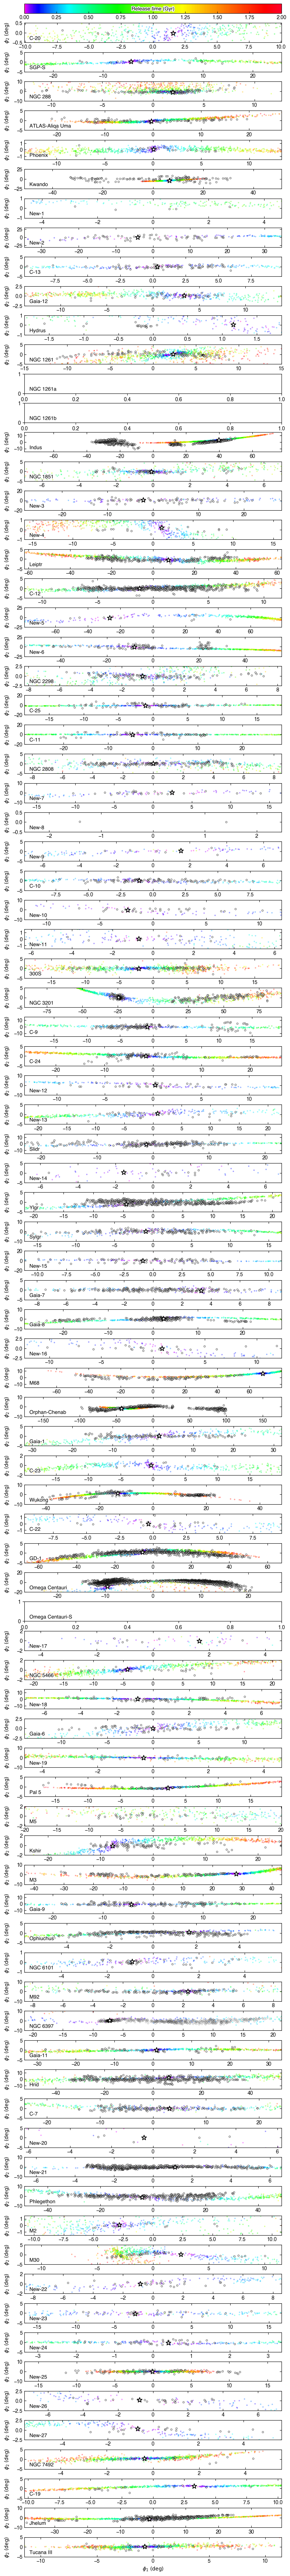

In [22]:
def round_range(x):
    if x <= 2.5:
        return 0.5 * ((x//0.5) + 1)
    if x <= 5:
        return 2.5 * ((x//2.5) + 1)
    if x <= 25:
        return 5 * ((x//5) + 1)
    return 10 * ((x//10) + 1)

mdot_dict = {}
mdot_alphas_dict = {}
mean_weight_alphas_dict = {}
t10_dict = {}
t90_dict = {}
n_obs_dict = {}
age_cuts = [8]

# mass_func = kroupa
imdividual_alpha = True
mass_func = lambda mmin, mmax: power_law_broken_imf(mmin, mmax, -1.5)
alphas = np.arange(-.5,2.01,0.1)
mass_funcs = [lambda mmin, mmax, alpha=alpha: power_law_imf(mmin, mmax, -alpha) for alpha in alphas]
yaxis = 'phi2'
distance_mode = 'mock' # mock or prog
mfmin = 0.08

sep_width = False

# fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,30), sharex=False, sharey=False)

fig = plt.figure(figsize=(9, 90))
gs = gridspec.GridSpec(len(gc_stream_ids)+1, 1, height_ratios=[0.5] + [1] * len(gc_stream_ids))
plt.subplots_adjust(hspace=0.5)
axs = [fig.add_subplot(gs[i+1]) for i in range(len(gc_stream_ids))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

# cmap = colormaps['gist_rainbow_r']
cmap = power_law_colormap('gist_rainbow_r', 0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.xaxis.set_label_position('bottom')

txt = cbar.ax.text(0.5, 0.45, r'Release time (Gyr)', transform=cbar.ax.transAxes, va='center', ha='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# for key, ax0 in zip(['Pal_5'], [axs[0]]):
for key, ax0 in zip(gc_stream_list, axs):
    txt = ax0.text(0.02, 0.08, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='bottom', ha='left')
    txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])
    
    print('')
    if not key in progs:
        print(name, 'not found')
        continue
    print(key, display_name_convert(key))
    
    stream = ds_i24[key]
    mockstream = mockstreams[key]
    
    # plot mock stars and prog GC
    x = mockstream.phi1
    x_prog = mockstream.prog_phi1
    if yaxis == 'phi2hat':
        y = mockstream.phi2hat
    elif yaxis == 'phi2':
        y = mockstream.phi2
    else:
        raise AttributeError
    ax0.scatter(x, y, s=7, ec='none', fc=cmap(-mockstream.release_time/t_tot.to_value('0.978*Gyr')), alpha=0.4, rasterized=True)
    
    # plot observed stars and prog GC
    x = stream.phi1
    x_prog = stream.prog_phi1
    if yaxis == 'phi2hat':
        y = stream.phi2hat
        y_prog = stream.prog_phi2hat
    elif yaxis == 'phi2':
        y = stream.phi2
        y_prog = stream.prog_phi2
    else:
        raise AttributeError
    alpha = 0.5
    if key == 'NGC_5139':
        alpha = 0.1
    if key == 'NGC_6397':
        alpha = 0.2
    ax0.scatter(x, y, s=10, marker='o', ec='k', fc='w', lw=1, alpha=alpha, rasterized=True)
    ax0.scatter(x_prog, y_prog, s=100, ec='k', fc='w', marker='*', lw=1.3)
    
    # # detect segments
    # segs = detect_segs(stream)
    # segs = segs_dict[key]
    # segs_left = detect_segs(stream, percentiles=[5,15])
    # segs_right = detect_segs(stream, percentiles=[85,95])
    
    # # distance and distance modulus
    # dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
    # dist_mod = 5*(np.log10(dist)+2)
    
    # # select isochrone
    # iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_gaia_list, 'G_BPmag', 'G_RPmag', 'Gmag')
    
    # # calculate mass of stars, minimum observable mass, maximum survived mass
    # masses = calc_mass(stream.mag - dist_mod, iso_gaia_list[iso_idx], 'Gmag')
    # mass_min = calc_mass(G_limit - dist_mod, iso_gaia_list[iso_idx], 'Gmag')
    # mass_max = np.max(iso_gaia_list[iso_idx]['Mini'][iso_gaia_list[iso_idx]['label']<=3])
    # mass_max = np.full_like(mass_min, fill_value=mass_max)
    
    # # weights of stars to correct for missing stars
    # if imdividual_alpha:
    #     mass_func = lambda mmin, mmax: power_law_imf(mmin, mmax, gc.loc[key]['MF'])
    #     weights = mass_func(mfmin, mass_max) / mass_func(mass_min, mass_max)
    # else:
    #     weights = mass_func(mfmin, mass_max) / mass_func(mass_min, mass_max)

    # # for alpha test
    # weights_alphas = []
    # for mf in mass_funcs:
    #     weights_alphas.append(mf(mfmin, mass_max) / mass_func(mass_min, mass_max))
    
    # # print('total mass = %g Msun'%np.sum(masses*weights))
    
    # mtot = 0
    # mtot_alphas = np.zeros_like(alphas, dtype=float)
    # t10 = np.inf
    # t90 = 0
    # n_obs = 0
    # select_weight_sum = np.zeros_like(age_cuts, dtype=float)
    # # now, look at individual segments
    # gaus_widths = calc_selection_function(stream, segs)
    # mock_gaus_widths = calc_selection_function(mockstream, segs)

    # for seg, width, mockwidth, seg_left, seg_right in zip(segs, gaus_widths, mock_gaus_widths, segs_left, segs_right):
    #     # decide the time range
    #     mask = (mockstream.phi1>=seg_left[0]) & (mockstream.phi1<=seg_left[1])
    #     select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
    #     t90_left = np.sum(-select_weights*mockstream.release_time[mask]*0.978) / np.sum(select_weights)
    #     mask = (mockstream.phi1>=seg_right[0]) & (mockstream.phi1<=seg_right[1])
    #     select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
    #     t90_right = np.sum(-select_weights*mockstream.release_time[mask]*0.978) / np.sum(select_weights)
    #     print('t90 of segment = %.2f Gyr'%np.nanmax([t90_left, t90_right]))
    #     t90 = np.nanmax([t90_left, t90_right]) if np.nanmax([t90_left, t90_right]) > t90 else t90
    #     t10 = np.nanmin([t90_left, t90_right]) if np.nanmin([t90_left, t90_right]) < t10 else t10
    
    # print('t90 from Gaia = %.2f Gyr'%t90)
    # t90_dict[key] = t90
    # t10_dict[key] = t10

    # weights_alphas_all = None
    
    # for seg, width, mockwidth in zip(segs, gaus_widths, mock_gaus_widths):
    #     if not sep_width:
    #         width = widths_dict[key]
    #         mockwidth = mockwidths_dict[key]
    #     # plot the Gaussian width
    #     for factor in [3]:
    #         if yaxis == 'phi2hat':
    #             x = seg
    #             y = np.zeros_like(seg)
    #         elif yaxis == 'phi2':
    #             x = np.linspace(seg[0], seg[1], 11)
    #             y = stream.fit_poly(x)
    #         ax0.fill_between(x, y-factor*width, y+factor*width, fc='k', ec='none', alpha=0.1)
    #         # ax0.plot(x, y+factor*width, c='w', alpha=1)
    #         # ax0.plot(x, y-factor*width, c='w', alpha=1)
    #     # ax0.fill_between(seg, -50,50, fc='k', ec='none', alpha=0.1)
    #     ax0.plot([seg[0],seg[0]], [-50, 50], c='gray', alpha=0.5, lw=1)
    #     ax0.plot([seg[1],seg[1]], [-50, 50], c='gray', alpha=0.5, lw=1)

    #     if distance_mode == 'prog':
    #         weights_seg = weights
    #         # for alpha test
    #         weights_alphas_seg =  weights_alphas
    #     elif distance_mode == 'mock':
    #         pd = pd_dict[key]     
    #         dist_seg = np.poly1d(pd)(stream.phi1)
    #         dist_mod_seg = 5*(np.log10(dist_seg)+2)
    #         mass_min_seg = calc_mass(G_limit - dist_mod_seg, iso_gaia_list[iso_idx], 'Gmag')
    #         weights_seg = mass_func(mfmin, mass_max) / mass_func(mass_min_seg, mass_max)
    #         # for alpha test
    #         weights_alphas_seg =  []
    #         for mf in mass_funcs:
    #             weights_alphas_seg.append(mf(mfmin, mass_max) / mf(mass_min_seg, mass_max))

    #     if weights_alphas_all is None:
    #         weights_alphas_all = np.array(weights_alphas_seg)
    #     else:
    #         weights_alphas_all = np.hstack([weights_alphas_all, weights_alphas_seg])
        
    #     mask = (stream.phi1>=seg[0]) & (stream.phi1<=seg[1])
    #     mseg = np.sum(masses[mask]*weights_seg[mask])
    #     print('mass of a segment = %g Msun'%mseg)
    #     mtot += mseg
    #     # for alpha test
    #     mseg_alphas = []
    #     for i, weights_alpha_seg in enumerate(weights_alphas_seg):
    #         mseg_alphas.append(np.sum(masses[mask]*weights_alpha_seg[mask]))
    #         mtot_alphas[i] += mseg_alphas[-1]
            
    #     n_obs += len(stream.phi1[mask])
    
    #     for i, age_cut in enumerate(age_cuts):
    #         mask = (mockstream.phi1>=seg[0]) & (mockstream.phi1<=seg[1]) & (-mockstream.release_time*0.978<age_cut)
    #         select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
    #         mdot = ndot * mseg / np.sum(select_weights)
    #         select_weight_sum[i] += np.sum(select_weights)
    
    #         print('mass loss rate of segment = %.2f Msun/Myr, age cut = %g Gyr'%(mdot,age_cut))
    
    # print('total mass from Gaia = %g Msun'%mtot)
    # for i, age_cut in enumerate(age_cuts):
    #     print('mass loss rate from Gaia = %.2f Msun/Myr, age cut = %g Gyr'%(ndot*mtot/select_weight_sum[i],age_cut))
    #     mdot_dict[key] = ndot*mtot/select_weight_sum
        
    # for i, mtot_alpha in enumerate(mtot_alphas):
    #     # print('mass loss rate from Gaia = %.2f Msun/Myr, alpha = %g'%(ndot*mtot_alpha/select_weight_sum[0],alphas[i]))
    #     mdot_alphas_dict[key] = ndot*mtot_alphas/select_weight_sum[0]
    #     mean_weight_alphas_dict[key] = np.mean(weights_alphas_all, axis=1)
        
    # n_obs_dict[key] = n_obs
    
    width = np.percentile(stream.phi1, 90) - np.percentile(stream.phi1, 10)
    # width = np.max(np.abs(segs))
    height = np.percentile(stream.phi2, 90) - np.percentile(stream.phi2, 10)
    ax0.set_xlim(-1.1*width,1.1*width)
    ylim = round_range(2*height)
    ax0.set_ylim(-ylim,ylim)
    ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')

    ax0.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)
    
ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
fig.align_ylabels(axs)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/stream_fit.pdf', dpi=300, bbox_inches ='tight')
# plt.savefig('/Users/ybchen/Downloads/stream_fit.png', dpi=300, bbox_inches ='tight')
plt.show()